# Module 3 Case Study — Teaching the Computer to Predict Loan Approval

**In plain English:** we already know (from projects 2 and 3) that credit
history is the biggest factor in whether a loan gets approved. This project
goes one step further: can the computer learn to *predict* approval on its
own, well enough to trust on a brand-new applicant it's never seen?

We try three different "guessing strategies" (models), test each one
properly (not just once, but many times in different ways), diagnose a
problem with one of them, fix it by tuning, and save the final version so it
can be reused without retraining.


In [1]:
import sys
sys.path.append("../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, learning_curve, StratifiedKFold
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import train as tr   # this project's src/train.py -- reused, not duplicated

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)


## 1. Load data and split into train / test

We reuse the already-cleaned, already-encoded dataset from project 2
(`loan_processed.csv`) -- this project is about the *modelling* workflow, not
re-cleaning data. The target, `Loan_Status`, is a bit imbalanced: about 69%
of applicants were approved, 31% weren't -- worth keeping in mind, since a
model that just guessed "approved" every time would already be right 69% of
the time.

In [2]:
X, y = tr.load_data()
print("Features:", X.columns.tolist())
print("Target balance:\n", y.value_counts(normalize=True).round(3))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print(f"\nTrain: {X_train.shape[0]} rows, Test: {X_test.shape[0]} rows")

Features: ['Married', 'Education', 'LoanAmount', 'Credit_History', 'Area_Rural', 'Area_Semiurban', 'Area_Urban']
Target balance:
 Loan_Status
1    0.687
0    0.313
Name: proportion, dtype: float64

Train: 491 rows, Test: 123 rows


## 2. Train three different model types

- **Logistic Regression** -- draws a simple straight-line-style boundary between approved/not approved.
- **K-Nearest Neighbours (KNN)** -- predicts based on the most similar past applicants.
- **Random Forest** -- a "committee" of many decision trees voting together.

All three are wrapped in the same kind of `Pipeline` (scale the numbers,
then predict), defined once in `src/train.py` so every model is treated fairly.

In [3]:
results = []
fitted_models = {}
for name, pipeline in tr.candidate_models().items():
    metrics = tr.evaluate(pipeline, X_train, y_train, X_test, y_test)
    cv_mean, cv_std = tr.cross_validate(pipeline, X, y)
    results.append({"model": name, **metrics, "cv_accuracy_mean": cv_mean, "cv_accuracy_std": cv_std})
    fitted_models[name] = pipeline

results_df = pd.DataFrame(results).set_index("model")
results_df.round(3)

,accuracy,precision,recall,f1,cv_accuracy_mean,cv_accuracy_std
model,,,,,,
Logistic Regression,0.854,0.832,0.988,0.903,0.808,0.019
KNN,0.821,0.839,0.918,0.876,0.795,0.012
Random Forest,0.724,0.840,0.741,0.788,0.713,0.029


## 3. Compare single train/test split vs. 5-fold cross-validation

A single train/test split can be lucky or unlucky depending on which rows
happened to land in the test set. Cross-validation instead splits the data
5 different ways and averages the result -- a more trustworthy estimate.

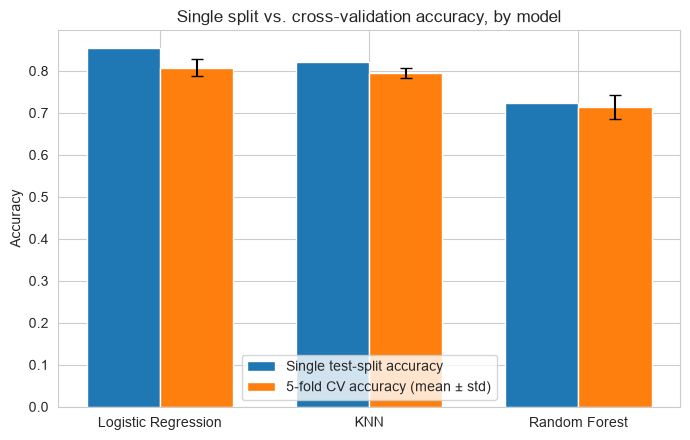

In [4]:
fig, ax = plt.subplots(figsize=(7, 4.5))
x = np.arange(len(results_df))
width = 0.35
ax.bar(x - width/2, results_df["accuracy"], width, label="Single test-split accuracy")
ax.bar(x + width/2, results_df["cv_accuracy_mean"], width, yerr=results_df["cv_accuracy_std"],
       label="5-fold CV accuracy (mean ± std)", capsize=4)
ax.set_xticks(x)
ax.set_xticklabels(results_df.index)
ax.set_ylabel("Accuracy")
ax.set_title("Single split vs. cross-validation accuracy, by model")
ax.legend()
plt.tight_layout()
plt.show()

**What this shows:** the single-split accuracy is a bit higher than the
cross-validated accuracy for every model -- a reminder that one lucky test
split can slightly overstate how good a model really is. The *ranking*
between models (Logistic Regression > KNN > Random Forest) stays the same
either way, which is reassuring.

## 4. Diagnose overfitting — Random Forest

Random Forest had by far the lowest test accuracy, despite being the most
complex model. Let's check whether it's *overfitting* -- memorising the
training data instead of learning a generalisable pattern.

In [5]:
rf_pipeline = tr.candidate_models()["Random Forest"]
train_acc, test_acc = tr.diagnose_overfitting(rf_pipeline, X_train, y_train, X_test, y_test)
print(f"Train accuracy: {train_acc:.3f}")
print(f"Test accuracy:  {test_acc:.3f}")
print(f"Gap:            {train_acc - test_acc:.3f}")

Train accuracy: 0.959
Test accuracy:  0.724
Gap:            0.236


That's a **24-point gap** between train and test accuracy -- a textbook
overfitting signature: the default Random Forest grows deep, unrestricted
trees that memorise quirks of the training rows instead of the general
pattern. A learning curve confirms it: training accuracy stays near-perfect
regardless of how much data it sees, while cross-validation accuracy lags
well behind.

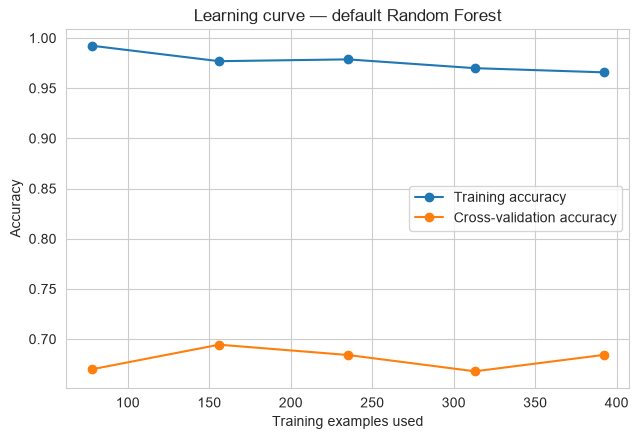

In [6]:
train_sizes, train_scores, val_scores = learning_curve(
    rf_pipeline, X_train, y_train, cv=StratifiedKFold(5, shuffle=True, random_state=42),
    train_sizes=np.linspace(0.2, 1.0, 5), scoring="accuracy"
)

plt.figure(figsize=(6.5, 4.5))
plt.plot(train_sizes, train_scores.mean(axis=1), "o-", label="Training accuracy")
plt.plot(train_sizes, val_scores.mean(axis=1), "o-", label="Cross-validation accuracy")
plt.xlabel("Training examples used")
plt.ylabel("Accuracy")
plt.title("Learning curve — default Random Forest")
plt.legend()
plt.tight_layout()
plt.show()

## 5. Fix it with `GridSearchCV`

We tune the Random Forest specifically because it's the one with a real
problem to fix (Logistic Regression was already close to its ceiling with
almost no hyperparameters to tune). `GridSearchCV` tries every combination
of a few settings and keeps whichever combination scores best under 5-fold
cross-validation.

In [7]:
grid = tr.tune_random_forest(X_train, y_train)
print("Best parameters:", grid.best_params_)
print(f"Best CV F1 score: {grid.best_score_:.3f}")

tuned_train_acc = (grid.predict(X_train) == y_train).mean()
tuned_test_acc = (grid.predict(X_test) == y_test).mean()
print(f"\nTuned Random Forest -- train accuracy: {tuned_train_acc:.3f}, test accuracy: {tuned_test_acc:.3f}")
print(f"Gap shrank from 0.236 to {tuned_train_acc - tuned_test_acc:.3f}")

Best parameters: {'clf__max_depth': 3, 'clf__min_samples_leaf': 5, 'clf__n_estimators': 200}
Best CV F1 score: 0.870

Tuned Random Forest -- train accuracy: 0.798, test accuracy: 0.854
Gap shrank from 0.236 to -0.055


**Restricting how deep and complex each tree is allowed to get** fixed the
overfitting: the train/test gap shrank dramatically, and test accuracy
*improved* even though train accuracy went down -- the model got less good
at memorising, and better at generalising. After tuning, Random Forest
reaches essentially the same test performance as Logistic Regression.

## 6. Final results table

In [8]:
tuned_metrics = tr.evaluate(grid.best_estimator_, X_train, y_train, X_test, y_test)
final_row = pd.DataFrame([{"model": "Random Forest (tuned)", **tuned_metrics,
                            "cv_accuracy_mean": grid.best_score_, "cv_accuracy_std": np.nan}]).set_index("model")
final_results = pd.concat([results_df, final_row])
final_results.round(3)

,accuracy,precision,recall,f1,cv_accuracy_mean,cv_accuracy_std
model,,,,,,
Logistic Regression,0.854,0.832,0.988,0.903,0.808,0.019
KNN,0.821,0.839,0.918,0.876,0.795,0.012
Random Forest,0.724,0.840,0.741,0.788,0.713,0.029
Random Forest (tuned),0.854,0.832,0.988,0.903,0.870,NaN


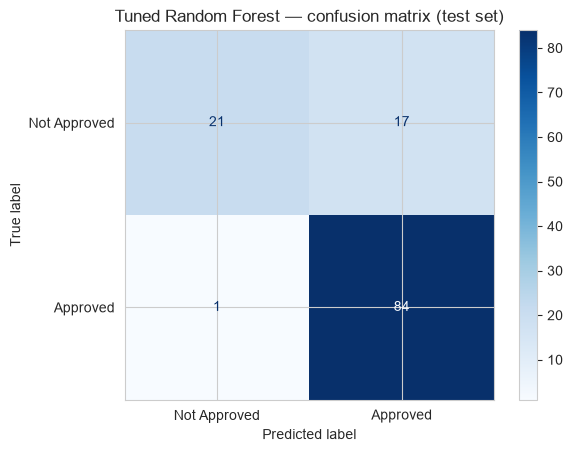

In [9]:
cm = confusion_matrix(y_test, grid.best_estimator_.predict(X_test))
ConfusionMatrixDisplay(cm, display_labels=["Not Approved", "Approved"]).plot(cmap="Blues")
plt.title("Tuned Random Forest — confusion matrix (test set)")
plt.show()

## 7. Save the final pipeline

`src/train.py` wraps every step above (load data, train, cross-validate,
diagnose, tune) into one script. Running it standalone reproduces everything
above and saves the tuned model + its preprocessing as one `Pipeline` object,
ready to reuse on new applicants without retraining.

In [10]:
tr.main()

=== Baseline model comparison ===
                     accuracy  precision  recall     f1  cv_accuracy_mean  \
model                                                                       
Logistic Regression     0.854      0.832   0.988  0.903             0.808   
KNN                     0.821      0.839   0.918  0.876             0.795   
Random Forest           0.724      0.840   0.741  0.788             0.713   

                     cv_accuracy_std  
model                                 
Logistic Regression            0.019  
KNN                            0.012  
Random Forest                  0.029  

=== Overfitting check (default Random Forest) ===
Train accuracy: 0.959 | Test accuracy: 0.724 | Gap: 0.236

=== Tuning Random Forest with GridSearchCV ===


Best params: {'clf__max_depth': 3, 'clf__min_samples_leaf': 5, 'clf__n_estimators': 200}
Best CV F1 score: 0.870
Tuned model -- train accuracy: 0.798 | test accuracy: 0.854



=== Final tuned model metrics on test set ===
  accuracy: 0.854
  precision: 0.832
  recall: 0.988
  f1: 0.903

Saved final tuned model -> C:\Users\neeha\OneDrive\Desktop\Gray Matter Technologies\GrayMatterTechnologies\04-module3-case-study-ml-pipeline\model.pkl


## Summary — plain English

- We tried three ways for the computer to guess loan approval: Logistic
  Regression, KNN, and Random Forest.
- **Logistic Regression won** on a single test split (85.4% accuracy) — the
  simplest model did the best job here.
- **Random Forest, by default, overfit badly** — it memorised 96% of the
  training data but only handled 72% of new data correctly. Cross-validation
  and a learning curve both confirmed this.
- Tuning Random Forest (mainly by limiting how deep each tree could grow)
  fixed the overfitting and brought its test accuracy up to match Logistic
  Regression's — while its train/test gap nearly disappeared.
- The final tuned model correctly predicts loan approval on about **85% of
  new applicants**, with a high recall (~99%) — meaning it rarely misses an
  applicant who should actually be approved.
- The whole workflow is saved as `src/train.py` + `model.pkl`, so it can be
  reused on new data without repeating any of this by hand.
